<a href="https://colab.research.google.com/github/poontamil-0807/Solar_Power_Output_Prediction/blob/main/solarpanel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import joblib

In [28]:
df=pd.read_csv("/content/solar_power_output (2).csv")
df.head()
df.tail()

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
495,18.833806,27.326566,701.391519,6.569552,352.480220
496,24.591403,93.385086,657.541311,9.566146,326.834297
497,11.943366,30.945490,517.144639,0.689580,259.133251
498,34.359870,96.018988,441.807202,0.570547,223.778239
499,34.655269,55.680462,877.000285,2.821871,435.410369


In [29]:
x=df[['temperature','humidity','solar_irradiance','wind_speed']]
y=df['solar_power_output']

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.9,random_state=55)
x_test

,temperature,humidity,solar_irradiance,wind_speed
84,17.774558,70.672068,950.258820,9.877855
309,16.770806,29.059044,833.342602,0.983956
33,33.722138,64.434536,208.510197,2.726240
370,12.519450,49.864745,974.255585,8.177853
6,11.452090,92.874175,723.048908,5.801724
201,12.103499,24.145883,122.128225,4.324979
286,21.639950,66.671344,179.079849,6.366697
463,24.584219,51.143649,692.060774,3.838330
38,27.105826,56.043531,158.820707,1.814383
186,30.430555,65.729015,719.097150,9.227572


In [20]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [21]:
y_pred=model.predict(x_test)
y_pred

array([474.30488111, 417.3022155 , 105.8253348 , 486.49875909,
       359.13909643,  61.91279439,  89.74982755, 346.80802577,
        80.5835199 , 360.49988849, 264.56940983,  70.01399189,
       363.93485694, 410.58365133, 411.10524194,  66.2039793 ,
       410.79226294, 437.3811109 , 411.46733634, 306.89157575,
       113.28794294, 370.36175271, 180.02017391, 160.81253138,
       192.35440014, 366.92419941, 181.55009601,  58.33164635,
        78.28589623, 331.93641939,  66.47668183,  68.50444995,
       249.19022336, 359.03790425, 124.43490621,  83.57445731,
       410.56660558, 253.58935449, 147.78385962, 243.25357197,
       116.24262403, 485.93902103,  54.37258627, 149.05273283,
       374.62052279, 442.93236733, 148.88452011, 352.08435234,
       204.03664742, 328.34363013])

In [31]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"mean squared error:{mse}")
print(f"R-squared:{r2}")

mean squared error:25.581948950741392
R-squared:0.9987459366112286


In [32]:
joblib.dump(model,'solar_power_prediction_model.pkl')

['solar_power_prediction_model.pkl']

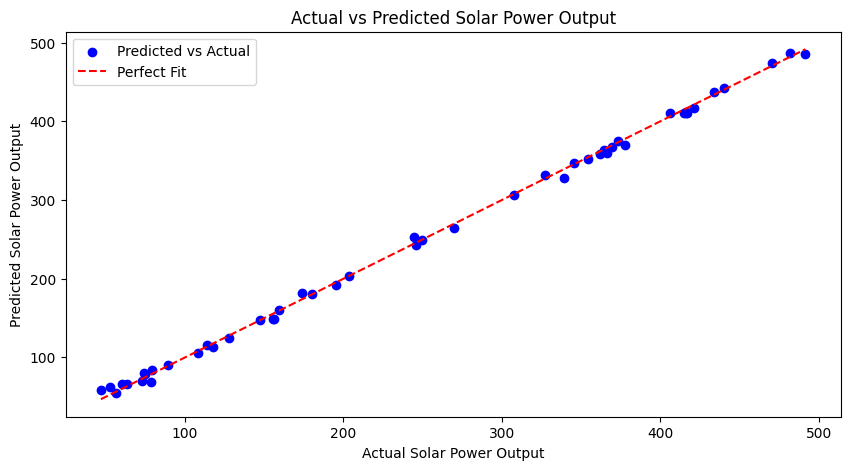

In [33]:
import matplotlib.pyplot as plt

# Scatter plot to compare actual vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
# Diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel("Actual Solar Power Output")
plt.ylabel("Predicted Solar Power Output")
plt.title("Actual vs Predicted Solar Power Output")
plt.legend()
plt.show()

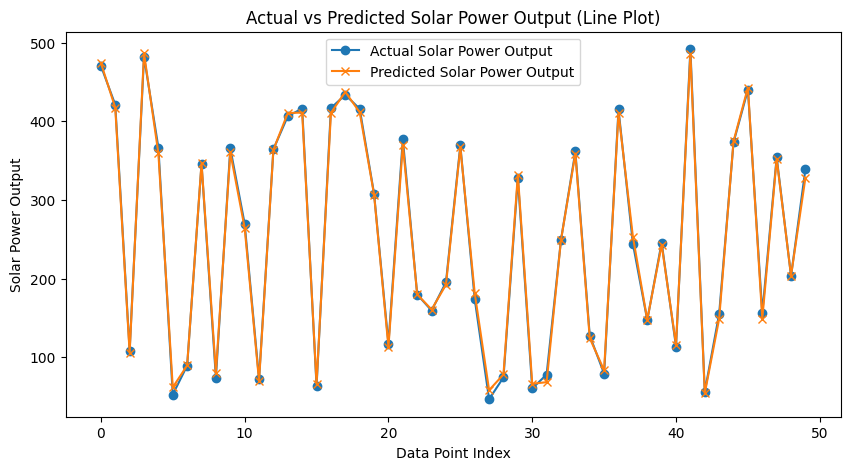

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test)), y_test, label="Actual Solar Power Output", marker='o')
plt.plot(range(len(y_test)), y_pred, label="Predicted Solar Power Output", marker='x')
plt.xlabel("Data Point Index")
plt.ylabel("Solar Power Output")
plt.title("Actual vs Predicted Solar Power Output (Line Plot)")
plt.legend()
plt.show()

In [35]:
model=joblib.load("solar_power_prediction_model.pkl")
new_data=np.array([[19.3,76.90,456.98,5.91]])
predicted_output=model.predict(new_data)
print(f"Predicted Solar Power Output:{predicted_output[0]}watts")

Predicted Solar Power Output:227.82368996694734watts


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
